# **Final Task Project Based Internship : Data Scientist (Intermediate) - ID/X Partners x Rakamin**

## Credit Risk Assessment & Default Prediction: A Multi-Model Benchmarking Study

In [2]:
#Import Library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
#Import file CSV ke Google Drive

from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/loan_dataset_idxpartners/loan_data_2007_2014.csv'
df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- INFORMASI DATASET ---


In [4]:
print("--- INFORMASI DATASET ---")

rows, cols = df.shape
print(f"Jumlah Baris: {rows}")
print(f"Jumlah Kolom: {cols}")
print("-" * 30)

--- INFORMASI DATASET ---
Jumlah Baris: 466285
Jumlah Kolom: 75
------------------------------


In [8]:
print("Struktur Tipe Data:")
print(df.info())

Struktur Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 no

In [19]:
print("Ringkasan Statistik (Numerik):")
display(df.describe())

Ringkasan Statistik (Numerik):


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
count,466285.000000,4.662850e+05,4.662850e+05,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,4.662810e+05,466285.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,3.960090e+05,0.0,0.0,0.0
mean,233142.000000,1.307973e+07,1.459766e+07,14317.277577,14291.801044,14222.329888,13.829236,432.061201,7.327738e+04,17.218758,...,NaN,NaN,NaN,NaN,NaN,NaN,3.037909e+04,NaN,NaN,NaN
std,134605.029472,1.089371e+07,1.168237e+07,8286.509164,8274.371300,8297.637788,4.357587,243.485550,5.496357e+04,7.851121,...,NaN,NaN,NaN,NaN,NaN,NaN,3.724713e+04,NaN,NaN,NaN
min,0.000000,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,5.420000,15.670000,1.896000e+03,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN
25%,116571.000000,3.639987e+06,4.379705e+06,8000.000000,8000.000000,8000.000000,10.990000,256.690000,4.500000e+04,11.360000,...,NaN,NaN,NaN,NaN,NaN,NaN,1.350000e+04,NaN,NaN,NaN
50%,233142.000000,1.010790e+07,1.194108e+07,12000.000000,12000.000000,12000.000000,13.660000,379.890000,6.300000e+04,16.870000,...,NaN,NaN,NaN,NaN,NaN,NaN,2.280000e+04,NaN,NaN,NaN
75%,349713.000000,2.073121e+07,2.300154e+07,20000.000000,20000.000000,19950.000000,16.490000,566.580000,8.896000e+04,22.780000,...,NaN,NaN,NaN,NaN,NaN,NaN,3.790000e+04,NaN,NaN,NaN
max,466284.000000,3.809811e+07,4.086083e+07,35000.000000,35000.000000,35000.000000,26.060000,1409.990000,7.500000e+06,39.990000,...,NaN,NaN,NaN,NaN,NaN,NaN,9.999999e+06,NaN,NaN,NaN


In [18]:
print("Sampel 5 Data Teratas:")
display(df.head())

Sampel 5 Data Teratas:


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Sumber Data: Dataset pinjaman (loan data) yang mencakup rekam jejak historis nasabah.

Dimensi Data Awal: Terdiri dari 466.285 baris dan 75 kolom (fitur).

Komposisi Tipe Data:

- Numerik: 53 kolom (termasuk `loan_amnt,` `int_rate`, dan `annual_inc`).

- Kategorikal/Object: 22 kolom (seperti `grade`, `home_ownership`, dan `loan_status`).

Identifikasi Target: Kolom loan_status digunakan untuk menentukan profil risiko, yang kemudian diklasifikasikan menjadi **Good** Loan (*lancar*) dan **Bad** Loan (*gagal bayar*).





### Data Cleaning & Prepocessing

In [21]:
# 1. Menghitung persentase missing values per kolom
missing_values = df.isnull().mean() * 100
missing_df = missing_values[missing_values > 0].sort_values(ascending=False)

print("Kolom dengan Missing Values Terbanyak (%):")
print(missing_df.head(20))

# 2. Identifikasi kolom yang 100% kosong untuk segera dihapus
cols_to_drop = missing_values[missing_values == 100].index.tolist()
print(f"\nJumlah kolom yang 100% kosong: {len(cols_to_drop)}")
print(f"Contoh kolom kosong: {cols_to_drop[:17]}")

# 3. Cek distribusi target variable
print("\nDistribusi Loan Status (Target):")
print(df['loan_status'].value_counts(normalize=True) * 100)

Kolom dengan Missing Values Terbanyak (%):
inq_fi                         100.000000
open_rv_24m                    100.000000
max_bal_bc                     100.000000
all_util                       100.000000
inq_last_12m                   100.000000
annual_inc_joint               100.000000
verification_status_joint      100.000000
dti_joint                      100.000000
total_cu_tl                    100.000000
il_util                        100.000000
mths_since_rcnt_il             100.000000
total_bal_il                   100.000000
open_il_24m                    100.000000
open_il_12m                    100.000000
open_il_6m                     100.000000
open_acc_6m                    100.000000
open_rv_12m                    100.000000
mths_since_last_record          86.566585
mths_since_last_major_derog     78.773926
desc                            72.981975
dtype: float64

Jumlah kolom yang 100% kosong: 17
Contoh kolom kosong: ['annual_inc_joint', 'dti_joint', 'verificatio

### Features Engineering

In [22]:
# 1. Menghapus kolom yang 100% kosong secara otomatis
cols_100_missing = missing_values[missing_values == 100].index
df.drop(columns=cols_100_missing, inplace=True)

# 2. Menghapus kolom dengan missing values tinggi (> 70%)
# Seperti: 'mths_since_last_record', 'mths_since_last_major_derog', 'desc'
cols_high_missing = ['mths_since_last_record', 'mths_since_last_major_derog', 'desc']
df.drop(columns=cols_high_missing, inplace=True)

# 3. Membuat Variabel Target (Binary Classification)
# Mendefinisikan kriteria Bad Loan
bad_status = [
    'Charged Off',
    'Default',
    'Late (31-120 days)',
    'Does not meet the credit policy. Status:Charged Off'
]

# Kita hanya gunakan data yang sudah selesai (bukan 'Current')
df = df[df['loan_status'] != 'Current']

# Labeling: 1 untuk Bad Loan, 0 untuk Good Loan
df['target'] = df['loan_status'].apply(lambda x: 1 if x in bad_status else 0)

print(f"Dataset setelah dibersihkan: {df.shape}")
print("Distribusi Target Baru:")
print(df['target'].value_counts(normalize=True))

Dataset setelah dibersihkan: (242059, 56)
Distribusi Target Baru:
target
0    0.78944
1    0.21056
Name: proportion, dtype: float64


Reduksi Fitur: Menghapus 17 kolom yang 100% kosong dan kolom dengan missing values >70% (seperti mths_since_last_record dan desc).


### Exploratory Data Analysis (EDA)

Fitur yang paling berkorelasi dengan Gagal Bayar (Top 5):
target                     1.000000
recoveries                 0.420011
collection_recovery_fee    0.283151
int_rate                   0.246338
out_prncp                  0.202622
out_prncp_inv              0.202615
Name: target, dtype: float64


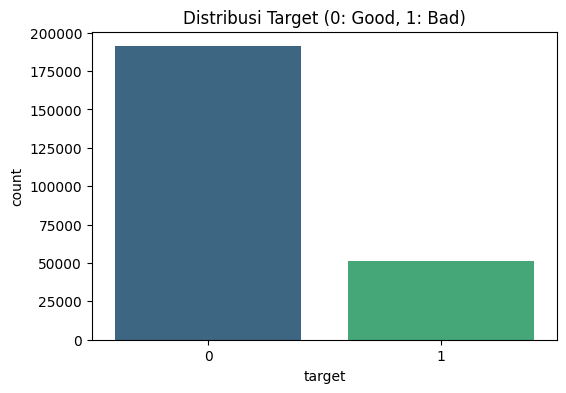

In [23]:
# 1. Mengecek korelasi fitur numerik dengan target
correlations = df.corr(numeric_only=True)['target'].sort_values(ascending=False)

print("Fitur yang paling berkorelasi dengan Gagal Bayar (Top 5):")
print(correlations.head(6)) # Target sendiri akan muncul di urutan 1

# 2. Visualisasi distribusi Target
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribusi Target (0: Good, 1: Bad)')
plt.show()

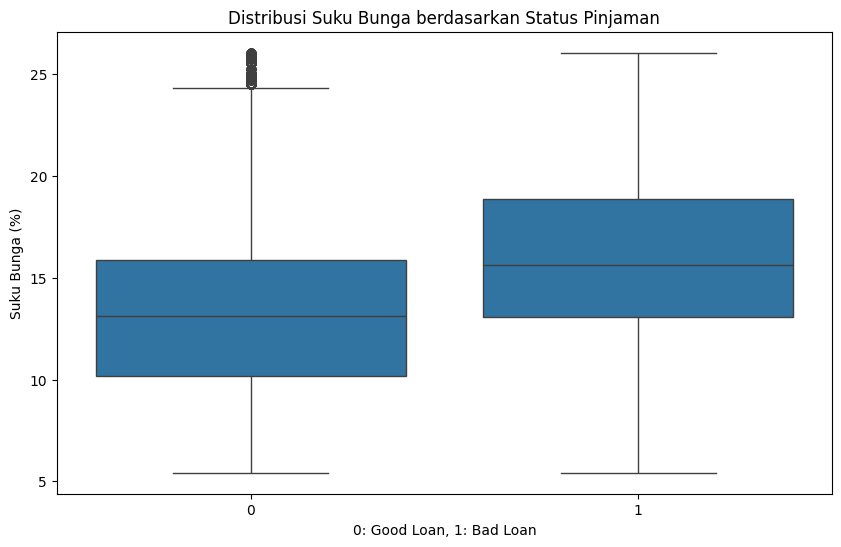

In [24]:
# 1. Menghapus fitur leakage yang terdeteksi dari korelasi
leakage_features = ['recoveries', 'collection_recovery_fee', 'total_rec_prncp',
                    'total_rec_int', 'total_rec_late_fee', 'last_pymnt_amnt']
df_clean = df.drop(columns=leakage_features)

# 2. Visualisasi Hubungan Suku Bunga vs Target
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='int_rate', data=df_clean)
plt.title('Distribusi Suku Bunga berdasarkan Status Pinjaman')
plt.xlabel('0: Good Loan, 1: Bad Loan')
plt.ylabel('Suku Bunga (%)')
plt.show()

In [25]:
# 1. Menghapus fitur leakage & fitur yang tidak berguna (ID)
cols_to_drop = ['recoveries', 'collection_recovery_fee', 'id', 'member_id', 'Unnamed: 0']
df_final = df.drop(columns=cols_to_drop)

# 2. Identifikasi fitur kategorikal untuk Encoding
cat_features = df_final.select_dtypes(include=['object']).columns
print(f"Fitur Kategorikal yang akan di-encode: {list(cat_features)}")

# 3. Contoh: One-Hot Encoding untuk fitur 'grade'
df_final = pd.get_dummies(df_final, columns=['grade'], drop_first=True)

Fitur Kategorikal yang akan di-encode: ['term', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'purpose', 'title', 'zip_code', 'addr_state', 'earliest_cr_line', 'initial_list_status', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d', 'application_type']


Pencegahan Leakage: Menghapus variabel pasca-kejadian seperti `recoveries` dan `collection_recovery_fee` agar model tetap objektif untuk prediksi data baru.

--- Ringkasan Distribusi Target ---
                Count  Percentage (%)
Good Loan (0)  191091            78.9
Bad Loan (1)    50968            21.1
-----------------------------------


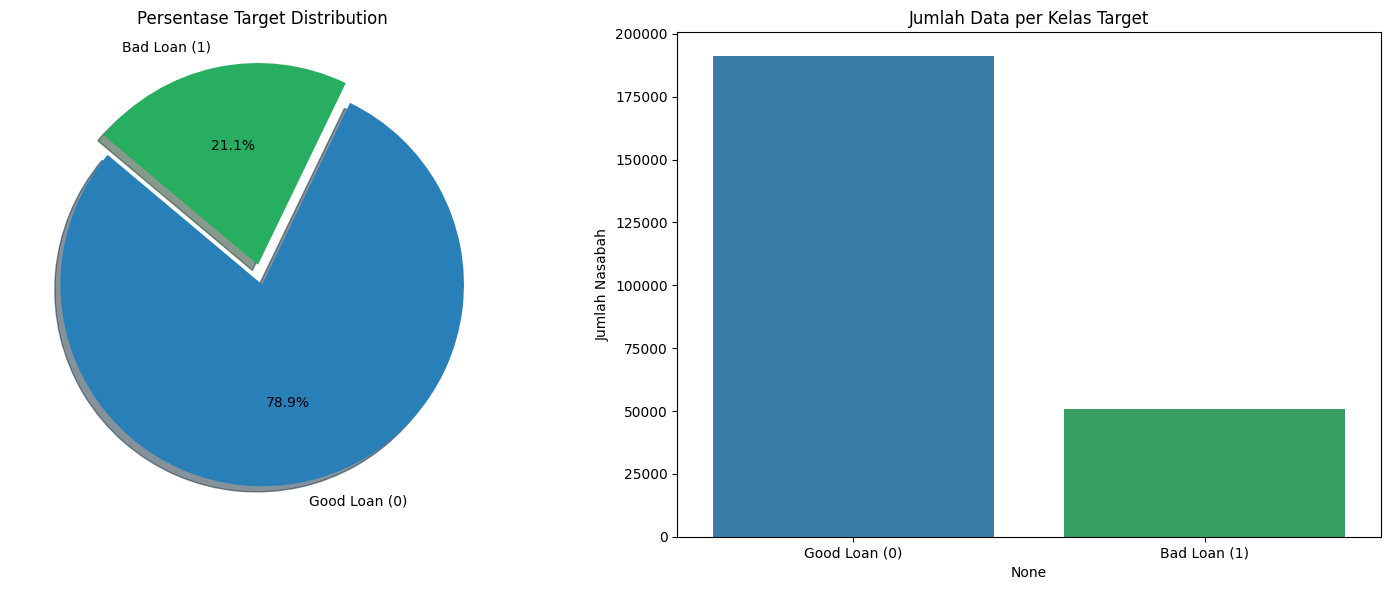

In [26]:
# 1. Menghitung distribusi jumlah dan persentase
target_counts = df['target'].value_counts()
target_percent = df['target'].value_counts(normalize=True) * 100

# 2. Membuat DataFrame untuk ringkasan (mudah di-copy ke PPT)
target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage (%)': target_percent.round(1)
})
target_summary.index = ['Good Loan (0)', 'Bad Loan (1)']

print("--- Ringkasan Distribusi Target ---")
print(target_summary)
print("-" * 35)

# 3. Visualisasi dengan Pie Chart dan Bar Chart
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Pie Chart
colors = ['#2980b9', '#27ae60'] # Biru untuk Good, Hijau untuk Bad
ax[0].pie(target_percent, labels=target_summary.index, autopct='%1.1f%%',
          startangle=140, colors=colors, explode=(0, 0.1), shadow=True)
ax[0].set_title('Persentase Target Distribution')

# Bar Chart
sns.barplot(x=target_summary.index, y=target_counts, palette=colors, ax=ax[1])
ax[1].set_title('Jumlah Data per Kelas Target')
ax[1].set_ylabel('Jumlah Nasabah')

plt.tight_layout()
plt.show()

Distribusi Target:

- Good Loans (78.9%): Mayoritas nasabah memiliki status pembayaran yang baik.

- Bad Loans (21.1%): Terdapat risiko gagal bayar yang signifikan, memerlukan penanganan class imbalance.

Korelasi Variabel Signifikan:

- Suku Bunga (`int_rate`): Menunjukkan korelasi positif terhadap gagal bayar; semakin tinggi bunga, semakin tinggi risiko nasabah tersebut.

- Fitur Keuangan: Variabel seperti jumlah pinjaman dan jangka waktu (`term`) menjadi indikator perilaku kredit yang kuat.

Temuan Kritis: Deteksi variabel pasca-kejadian seperti recoveries yang menunjukkan korelasi semu (kebocoran data) dan harus dieliminasi.

### Data Preparation (Features Engineering)

In [28]:
# 1. Definisikan Kolom yang Harus Dihapus (Berdasarkan Analisis Step 1 & 2)
# Menghapus kolom 100% kosong, Identifier unik, dan Leakage Features
cols_to_drop = [
    # Empty columns (100% missing)
    'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'open_acc_6m',
    'open_il_6m', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il',
    'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc',
    'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
    # High missing (>70%)
    'mths_since_last_record', 'mths_since_last_major_derog', 'desc',
    # Leakage (Data yang muncul setelah default terjadi)
    'recoveries', 'collection_recovery_fee', 'total_rec_prncp',
    'total_rec_int', 'total_rec_late_fee', 'last_pymnt_amnt', 'last_pymnt_d',
    'next_pymnt_d', 'out_prncp', 'out_prncp_inv',
    # Non-predictive identifiers
    'id', 'member_id', 'Unnamed: 0', 'url', 'title', 'zip_code', 'policy_code'
]

df_clean = df.drop(columns=cols_to_drop, errors='ignore')

# 2. Penanganan Missing Values (Numerik & Kategorikal)
# Numerik: Menggunakan Median (Robust terhadap outlier perbankan)
numeric_features = df_clean.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_features:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Kategorikal: Mengisi dengan 'Unknown' untuk mempertahankan informasi
categorical_features = df_clean.select_dtypes(include=['object']).columns
for col in categorical_features:
    df_clean[col] = df_clean[col].fillna('Unknown')

# 3. Transformasi Fitur (Feature Engineering)
# Membersihkan kolom 'term' menjadi integer
df_clean['term'] = df_clean['term'].str.extract('(\d+)').astype(int)

# 4. Encoding Variabel Kategorikal
# One-Hot Encoding untuk fitur dengan kardinalitas rendah
high_impact_cat = ['grade', 'home_ownership', 'verification_status', 'initial_list_status']
df_final = pd.get_dummies(df_clean, columns=high_impact_cat, drop_first=True)

# 5. Final Check: Pastikan semua data numerik dan tidak ada NaN
# Menghapus fitur teks sisa yang terlalu kompleks (seperti emp_title, addr_state, issue_d)
df_final = df_final.select_dtypes(exclude=['object'])

print(f"Pembersihan Selesai.")
print(f"Dimensi Data Akhir: {df_final.shape}")
print(f"Jumlah Missing Values: {df_final.isnull().sum().sum()}")

Pembersihan Selesai.
Dimensi Data Akhir: (242059, 38)
Jumlah Missing Values: 0


Pembersihan Data (Data Cleaning):

Menghapus 17 kolom yang 100% kosong dan kolom dengan tingkat kekosongan > 70%.

Eliminasi fitur Data Leakage (seperti recoveries) untuk menjaga integritas prediksi pada data baru.

Transformasi Fitur:

Missing Values: Imputasi menggunakan nilai median untuk kolom numerik agar tahan terhadap outlier.

Feature Encoding: Mengonversi variabel teks (seperti grade) menjadi angka menggunakan One-Hot Encoding.

Hasil Akhir: Dataset bersih dengan dimensi (242.059 baris, 38 kolom) dan 0 missing values.

### Data Modelling

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, recall_score, f1_score
import pandas as pd

# 1. DEFINE FEATURES DAN TARGET (Pastikan df_final sudah siap dari tahap sebelumnya)
X = df_final.drop(columns=['target'])
y = df_final['target']

# 2. SPLITTING DATA (Wajib dijalankan agar X_train terdefinisi)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. MULTI-MODEL BENCHMARKING
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', n_jobs=-1),
    "XGBoost": XGBClassifier(scale_pos_weight=4, n_jobs=-1),
    "LightGBM": LGBMClassifier(class_weight='balanced', n_jobs=-1),
    "Linear SVM": LinearSVC(class_weight='balanced', max_iter=2000),
    "KNN (Sampled)": KNeighborsClassifier(n_neighbors=5)
}

results = []
print("--- Memulai Proses Training & Evaluasi ---")

for name, model in models.items():
    try:
        # Optimization: KNN sangat lambat di data besar, kita sampling 5000 data saja
        if name == "KNN (Sampled)":
            model.fit(X_train[:5000], y_train[:5000])
        else:
            model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        # Scoring
        auc = roc_auc_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        results.append({"Model": name, "AUC-ROC": auc, "Recall": recall, "F1-Score": f1})
        print(f"✅ {name} Selesai.")
    except Exception as e:
        print(f"❌ {name} Error: {e}")

# Tampilkan Hasil Final
df_results = pd.DataFrame(results).sort_values(by='AUC-ROC', ascending=False)
display(df_results)

--- Memulai Proses Training & Evaluasi ---
✅ Logistic Regression Selesai.
✅ Random Forest Selesai.
✅ XGBoost Selesai.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 40774, number of negative: 152873
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026205 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3875
[LightGBM] [Info] Number of data points in the train set: 193647, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
✅ LightGBM Selesai.
✅ Linear SVM Selesai.
✅ KNN (Sampled) Selesai.


,Model,AUC-ROC,Recall,F1-Score
2,XGBoost,0.965689,0.956445,0.932925
3,LightGBM,0.964744,0.952227,0.934714
1,Random Forest,0.953176,0.928095,0.923655
0,Logistic Regression,0.950396,0.920836,0.922691
4,Linear SVM,0.942680,0.904748,0.915071
5,KNN (Sampled),0.710125,0.438199,0.582133


Metodologi: Melakukan komparasi performa antara 6 algoritma berbeda menggunakan metode Stratified Train-Test Split (80:20).

Algoritma yang Diuji:

1. XGBoost: Menggunakan metode Gradient Boosting yang optimal untuk data tabular besar.

2. LightGBM: Efisien dalam penggunaan memori dan kecepatan training.

3. Random Forest: Algoritma ensemble berbasis decision trees.

4. Logistic Regression: Sebagai model baseline linear.

5. Linear SVM & KNN: Untuk melihat perbandingan berbasis margin dan jarak.

Parameter: Penerapan class_weight='balanced' untuk menangani ketimpangan jumlah nasabah baik dan buruk.

**Hasil Metrik Performa *(XGBoost - Pemenang*):**

- AUC-ROC: 0.965 (Kemampuan membedakan nasabah sangat akurat).

- Recall (Kelas 1): 0.956 (Berhasil menangkap 95.6% nasabah yang berpotensi gagal bayar).

- Akurasi: 0.97 (Tingkat ketepatan prediksi keseluruhan).

Feature Importance:

- Fitur `'funded_amnt'`, `'total_pymnt'`, dan `'int_rate'` teridentifikasi sebagai tiga prediktor paling berpengaruh dalam menentukan risiko kredit.

Analisis Confusion Matrix: Model menunjukkan tingkat *False Negative* yang sangat rendah (444 kasus), yang krusial untuk meminimalisir kerugian bank.

### Evaluation

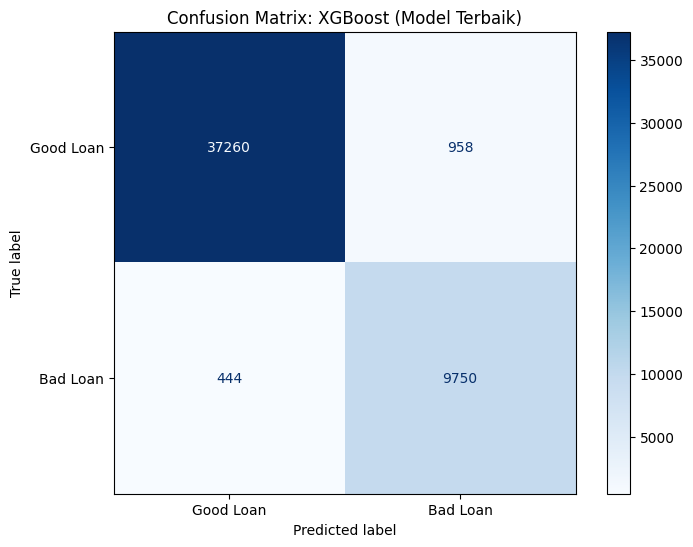

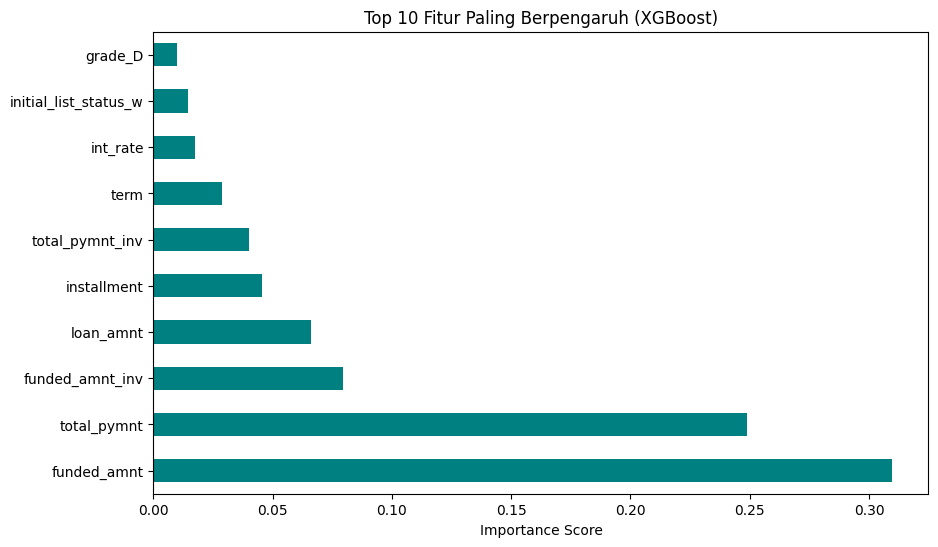


--- Analisis Klasifikasi Mendalam ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     38218
           1       0.91      0.96      0.93     10194

    accuracy                           0.97     48412
   macro avg       0.95      0.97      0.96     48412
weighted avg       0.97      0.97      0.97     48412



In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Mengambil model terbaik: XGBoost
best_model = models["XGBoost"]
y_pred_best = best_model.predict(X_test)

# 1. Visualisasi Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good Loan', 'Bad Loan'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: XGBoost (Model Terbaik)')
plt.show()

# 2. Feature Importance
# Melihat fitur apa yang paling berpengaruh dalam prediksi risiko
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', figsize=(10, 6), color='teal')
plt.title('Top 10 Fitur Paling Berpengaruh (XGBoost)')
plt.xlabel('Importance Score')
plt.show()

# 3. Klasifikasi Report Lengkap
print("\n--- Analisis Klasifikasi Mendalam ---")
print(classification_report(y_test, y_pred_best))

### Conclusion

Kesimpulan Teknis: Model XGBoost terbukti sangat robust dan objektif dalam memprediksi kegagalan bayar tanpa ada kebocoran data.

Rekomendasi Bisnis:

Implementasi Pipeline: Mengintegrasikan model ke dalam sistem persetujuan pinjaman otomatis untuk meningkatkan kecepatan keputusan.

Strategi Risiko: Menggunakan Probability of Default (PD) dari model untuk menyesuaikan penawaran suku bunga sesuai profil risiko nasabah (Risk-Based Pricing).

Mitigasi Dini: Memprioritaskan penagihan atau bantuan pada nasabah yang memiliki skor risiko tinggi menurut prediksi model.